
# Del 2 – Dataanalys och strukturering av kod

Här nedan läser vi in datasette 'health_study_dataset.csv' och definierar vilka kolumner vi vill analysera.
Efter det skapas ett 'Healthanalyser'-objekt som jag kommer använda för alla analyser och viualiseringar i denna notebook.

In [1]:
import pandas as pd
from health_analyzer import HealthAnalyzer
from sklearn.metrics import r2_score

df = pd.read_csv("../data/health_study_dataset.csv")
columns = ['age','weight','height','systolic_bp','cholesterol']

# Skapa analys-objekt
analyzer = HealthAnalyzer(df)

# Statistik
Beräknar medelvärde, median, min och max för de valda kolumnerna.  
Detta ger en första överblick över datasetet och hjälper oss att förstå fördelningen av vikt, ålder, blodtryck och kolesterol.


In [2]:
stats_table = analyzer.stats(columns)
stats_table

,Medel,Median,Min,Max
age,49.43,50.00,18.0,90.00
weight,73.41,73.20,33.7,114.40
height,171.85,171.35,144.4,200.40
systolic_bp,149.18,149.40,106.8,185.90
cholesterol,4.93,4.97,2.5,7.88


# Grafer
Här ritas de olika diagram ut för att undersöka mönster i datan:

- Histogram: Visar fördelningen av systoliskt blodtryck i populationen.
- Boxplot: Visar viktfördelning per kön, inklusive median och spridning.
- Stapeldiagram: Visar andelen rökare och icke-rökare.
- Scatterplot: Visar sambandet mellan ålder och systoliskt blodtryck. Ny plot för del 2.


Histogram över systoliskt blodtryck:


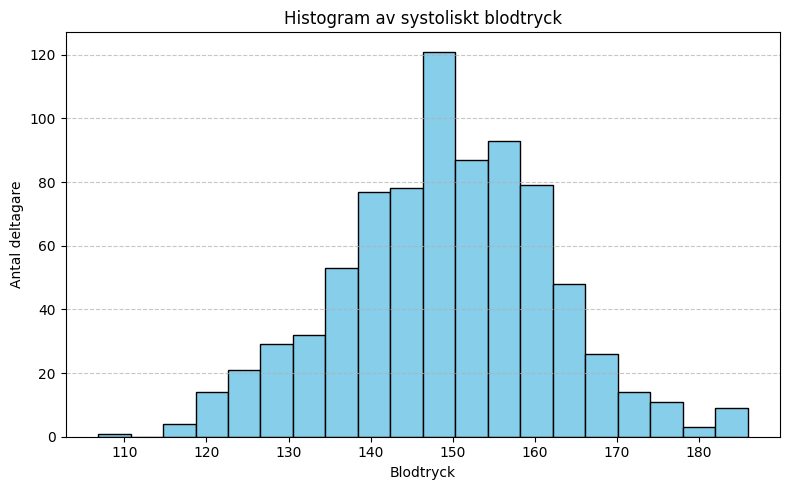

Boxplot över vikt per kön:


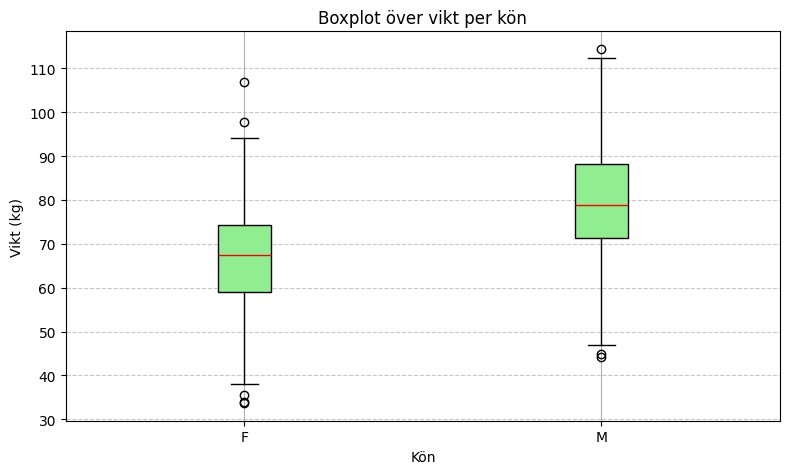

Stapeldiagram över rökare:


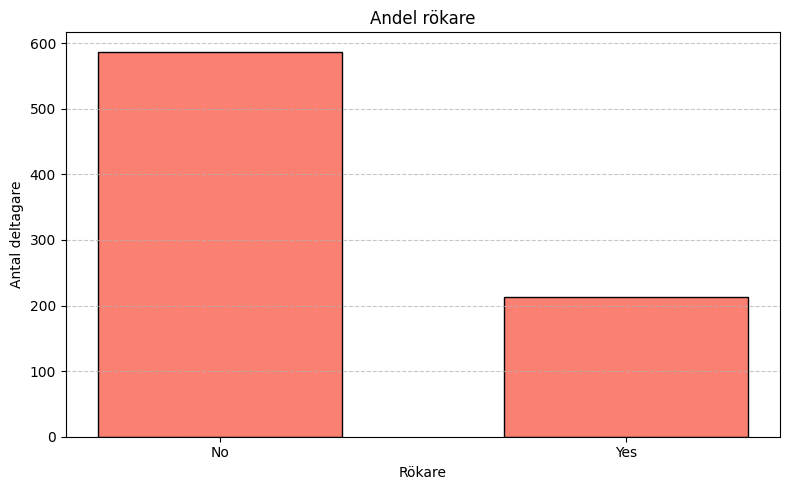

Scatterplot över ålder vs blodtryck


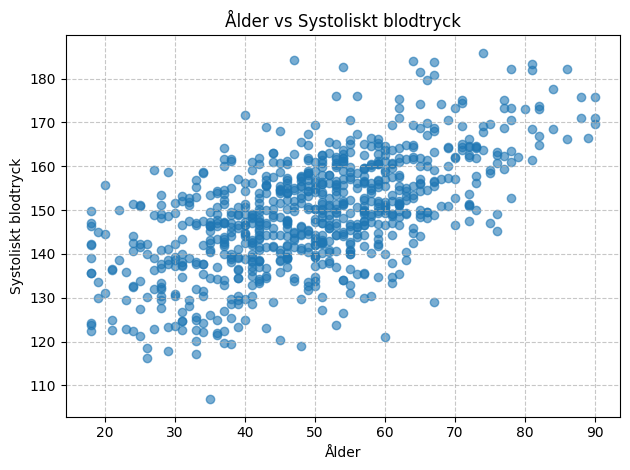

In [3]:
print("Histogram över systoliskt blodtryck:")
analyzer.histogram_bp()

print("Boxplot över vikt per kön:")
analyzer.boxplot_weight()

print("Stapeldiagram över rökare:")
analyzer.bar_smokers()

print("Scatterplot över ålder vs blodtryck")
analyzer.scatter_age_bp() 

# Simulering
Här simuleras andelen personer med sjukdom baserat på den observerade andelen i datasetet.  
Vi jämför den verkliga andelen med resultatet från simuleringen med 1000 personer.

In [4]:
simulated_rate = analyzer.simulate_disease(n=1000, seed=42)
actual_rate = df['disease'].mean()

print(f"Verklig andel med sjukdom: {actual_rate:.3f}")
print(f"Simulerad andel med sjukdom (1000 personer): {simulated_rate:.3f}")

Verklig andel med sjukdom: 0.059
Simulerad andel med sjukdom (1000 personer): 0.056


# Konfidensintervall
Här beräknas ett 95% konfidensintervall för medelvärdet av systoliskt blodtryck i datasetet.  
Konfidensintervallet ger ett mått på osäkerheten kring medelvärdet.

In [5]:
ci_low, ci_high = analyzer.ci_bp()

95% CI för systoliskt blodtryck: [148.29, 150.07]



# Hypotesprövning: Rökare vs icke-rökare
Utförde ett t-test (Welch's) för att jämföra medelvärdet av systoliskt blodtryck mellan rökare och icke-rökare.  
Testet avgör om skillnaden mellan grupperna är statistiskt signifikant eller inte.

In [6]:
t_stat, p_value, n_smokers, n_nonsmokers = analyzer.ttest_smokers()

print(f"Antal rökare: {n_smokers}")
print(f"Antal icke-rökare: {n_nonsmokers}")
print(f"T-värde: {t_stat:.4f}")
print(f"P-värde: {p_value:.4f}")

if p_value < 0.05:
    print("Skillnaden mellan grupperna är statistiskt signifikant.")
else:
    print("Ingen statistiskt signifikant skillnad mellan grupperna.")

Antal rökare: 213
Antal icke-rökare: 587
T-värde: 0.4503
P-värde: 0.6527
Ingen statistiskt signifikant skillnad mellan grupperna.


# Dubbelhistogram - Rökare vs icke-rökare
Här ser man fördelningen av systoliskt blodtryck för rökare och icke-rökare i samma diagram.  
Histogrammen är överlagrade för att lättare jämföra skillnader mellan grupperna.

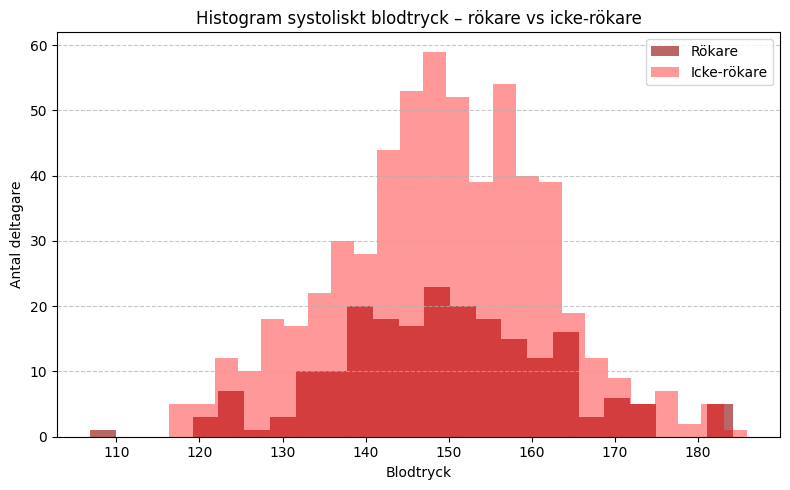

In [7]:
analyzer.histogram_smoker_groups()

# Linjär regression
I detta steg tränas en linjär regressionsmodell som förklarar hur systoliskt blodtryck påverkas av både ålder och vikt. Modellen presenterar intercept, koefficienter för respektive variabel samt en prediktion för en person som är 45 år och väger 70 kg.

In [8]:
model = analyzer.regression_age_weight_bp()

print(f"Intercept (startvärde för blodtryck): {model.intercept_:.2f}")
print(f"Koefficienter (lutning): Age -> {model.coef_[0]:.2f}, Weight -> {model.coef_[1]:.2f}")

new_data = pd.DataFrame({'age': [45], 'weight': [70]})
predicted_bp = model.predict(new_data)  
print(f"Predikterat systoliskt blodtryck för 45 år, 70 kg: {predicted_bp[0]:.2f}")

Intercept (startvärde för blodtryck): 109.50
Koefficienter (lutning): Age -> 0.54, Weight -> 0.18
Predikterat systoliskt blodtryck för 45 år, 70 kg: 146.19


# Regression: scatter + prediktionslinje
Visar en scatterplot över ålder & vikt vs. systoliskt blodtryck med regressionens prediktionslinje. R^2-värdet beräknas för att visa hur väl modellen förklarar variationen i blodtryck.

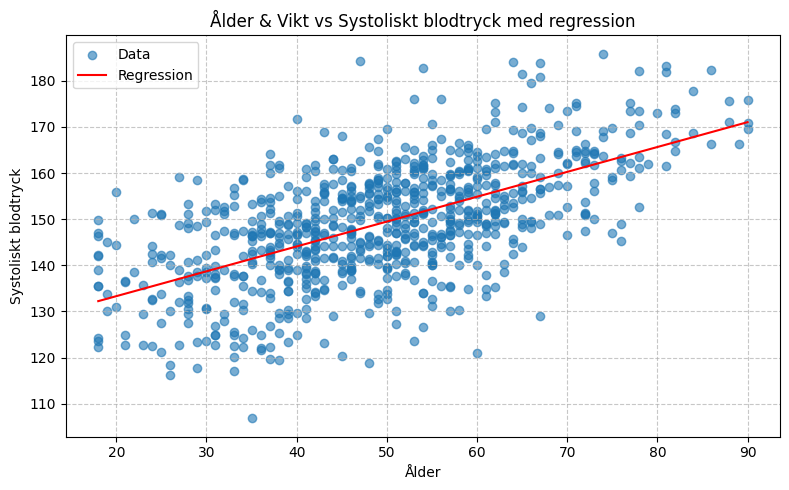

R^2 för regressionen: 0.405


In [9]:
analyzer.plot_regression()                   

df_clean = df.dropna(subset=['age','weight','systolic_bp'])
X = df_clean[['age','weight']]
y = df_clean['systolic_bp']
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R^2 för regressionen: {r2:.3f}")
